In [21]:
# Lab 5a
# Using models to make image based predictions
# What is the image most likely

import torch
import torchvision.transforms.v2 as transforms
import torchvision.io as tv_io
import matplotlib.pyplot as plt

import json
import platform
from utils import show_image, mpimg
print("Torch Loaded")

Torch Loaded


In [34]:
def get_platform_device():
    '''

    Detects the OS and the best GPU to use on the device

    '''
    
    os_name = platform.system()
    processor = platform.processor()
    

    if torch.cuda.is_available():
        device = torch.device("cuda")
        platform_info = f"Nvidia GPU via CUDA ({os_name})"
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        platform_info = f"Apple Silicon via MPS ({os_name})"
    else:
        device = torch.device("cpu")
        platform_info = f"CPU fallback ({os_name} {processor})"
    
    print(f"Platform detected: {platform_info}")
    return device

device = get_platform_device()
print(f"Using device: {device}")

Platform detected: Apple Silicon via MPS (Darwin)
Using device: mps


In [14]:
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

# load the VGG16 network *pre-trained* on the ImageNet dataset
weights = VGG16_Weights.DEFAULT
model = vgg16(weights=weights)

In [15]:
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [16]:
pre_trans = weights.transforms()
pre_trans

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

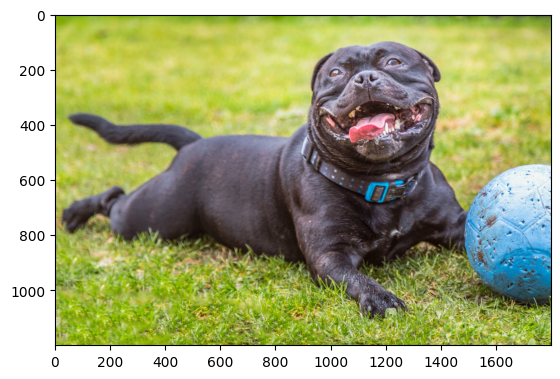

In [17]:
show_image("data/doggy_door_images/happy_dog.jpg") #Defined in utils

In [18]:
print(device)
def load_and_process_image(file_path):
    # Print image's original shape, for reference
    print('Original image shape: ', mpimg.imread(file_path).shape)
    
    image = tv_io.read_image(file_path).to(device)
    image = pre_trans(image)  # weights.transforms()
    image = image.unsqueeze(0)  # Turn into a batch
    return image

mps


In [19]:
processed_image = load_and_process_image("data/doggy_door_images/happy_dog.jpg")
print("Processed image shape: ", processed_image.shape)

Original image shape:  (1200, 1800, 3)
Processed image shape:  torch.Size([1, 3, 224, 224])


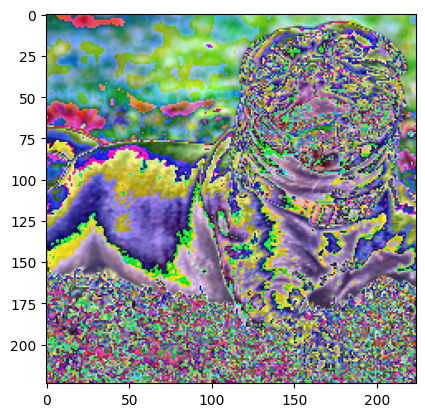

In [22]:
import torchvision.transforms.functional as F

plot_image = F.to_pil_image(torch.squeeze(processed_image))
plt.imshow(plot_image, cmap='gray')

In [23]:
vgg_classes = json.load(open("data/imagenet_class_index.json"))

In [24]:
vgg_classes["0"]

['n01440764', 'tench']

In [25]:
def readable_prediction(image_path):
    # Show image
    show_image(image_path)
    # Load and pre-process image
    image = load_and_process_image(image_path)
    # Make predictions
    output = model(image)[0]  # Unbatch
    predictions = torch.topk(output, 3)
    indices = predictions.indices.tolist()
    # Print predictions in readable form
    out_str = "Top results: "
    pred_classes = [vgg_classes[str(idx)][1] for idx in indices]
    out_str += ", ".join(pred_classes)
    print(out_str)

    return predictions

Original image shape:  (1200, 1800, 3)
Top results: Staffordshire_bullterrier, American_Staffordshire_terrier, pug


torch.return_types.topk(
values=tensor([16.6494, 14.4439, 14.4118], device='mps:0', grad_fn=<TopkBackward0>),
indices=tensor([179, 180, 254], device='mps:0'))

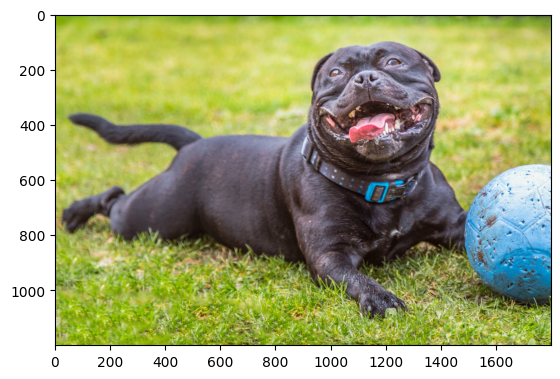

In [26]:
readable_prediction("data/doggy_door_images/happy_dog.jpg")

Original image shape:  (2592, 3456, 3)
Top results: brown_bear, American_black_bear, sloth_bear


torch.return_types.topk(
values=tensor([40.3004, 30.1505, 26.7260], device='mps:0', grad_fn=<TopkBackward0>),
indices=tensor([294, 295, 297], device='mps:0'))

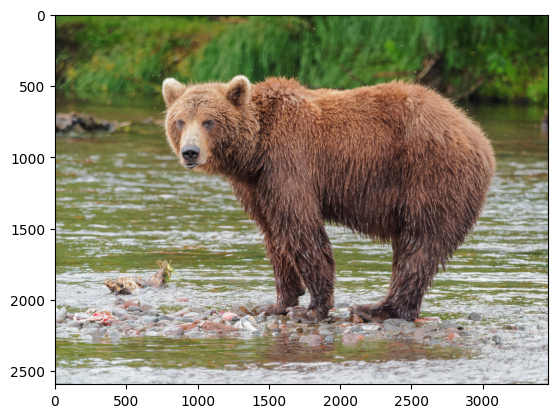

In [27]:
readable_prediction("data/doggy_door_images/brown_bear.jpg")

Original image shape:  (1200, 1800, 3)
Top results: tiger_cat, Persian_cat, tabby


torch.return_types.topk(
values=tensor([16.3971, 13.3624, 12.9315], device='mps:0', grad_fn=<TopkBackward0>),
indices=tensor([282, 283, 281], device='mps:0'))

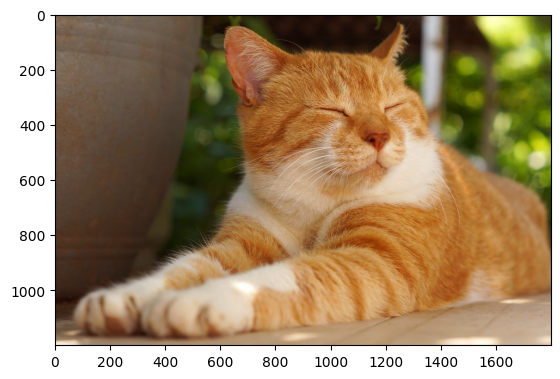

In [28]:
readable_prediction("data/doggy_door_images/sleepy_cat.jpg")

In [30]:
import numpy as np

def doggy_door(image_path):
    show_image(image_path)
    image = load_and_process_image(image_path)
    idx = model(image).argmax(dim=1).item()
    print("Predicted index:", idx)
    if 151 <= idx <= 268:
        print("Doggy come on in!")
    elif 281 <= idx <= 285:
        print("Kitty stay inside!")
    else:
        print("You're not a dog! Stay outside!")

Original image shape:  (2592, 3456, 3)
Predicted index: 294
You're not a dog! Stay outside!


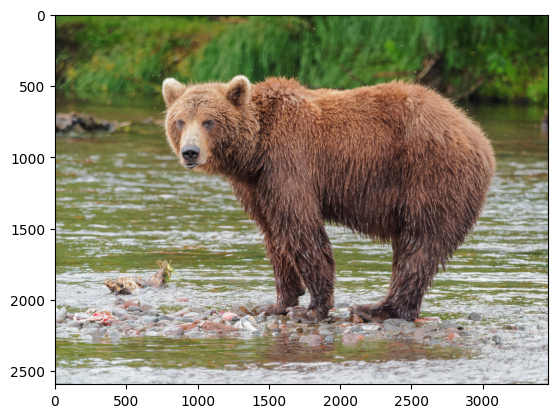

In [31]:
doggy_door("data/doggy_door_images/brown_bear.jpg")

Original image shape:  (1200, 1800, 3)
Predicted index: 179
Doggy come on in!


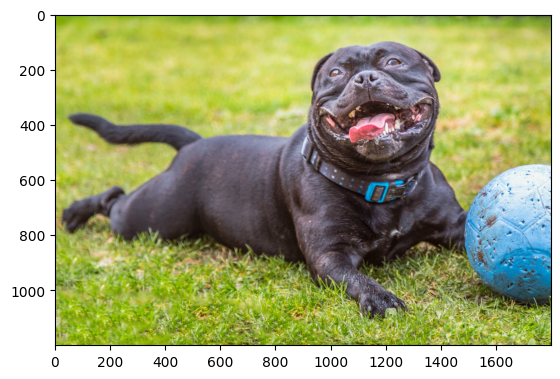

In [32]:
doggy_door("data/doggy_door_images/happy_dog.jpg")

Original image shape:  (1200, 1800, 3)
Predicted index: 282
Kitty stay inside!


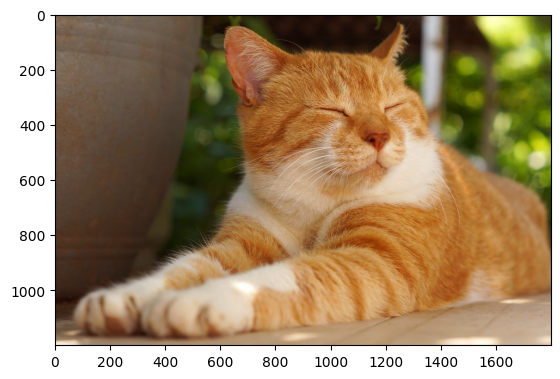

In [33]:
doggy_door("data/doggy_door_images/sleepy_cat.jpg")